# Native FSim Compiler: differentiable and Riemannian synthesis on U(4)

**Author:** Jasper Sands · **Package:** `cirq_fsim_compiler` v0.3.0

1. The FSim gate and the synthesis template
2. Free-angle synthesis of the standard gates: one FSim each
3. Calibrated native gate: how many Sycamore FSim(π/2, π/6) does each gate need?
4. Euclidean (L-BFGS) versus Riemannian (Cayley retraction) solvers
5. Calibration drift: recompiling on a drifted coupler
6. Whole circuits through the Cirq transformer; Toffoli / Fredkin / CCZ / QFT
7. OpenQASM 3 export and round trip

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import cirq
from cirq_fsim_compiler import (
    fsim_matrix_np, haar_random_unitary, DifferentiableFSimSynthesizer, synthesize_unitary_to_fsim,
    CouplerCalibration, SycamoreCalibrationMap, compile_to_fsim, decompose_toffoli_to_sycamore,
    decompose_fredkin_to_sycamore, decompose_qft3_to_sycamore, qft_unitary,
    export_to_openqasm3, parse_openqasm3, __version__,
)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
print("cirq_fsim_compiler", __version__, "| cirq", cirq.__version__)
fid = lambda u, v: abs(np.trace(u.conj().T @ v))**2 / u.shape[0]**2

cirq_fsim_compiler 0.3.0 | cirq 1.7.0


## 1. The FSim gate

$\mathrm{FSim}(\theta,\varphi) = \begin{pmatrix}1&&&\\&\cos\theta&-i\sin\theta&\\&-i\sin\theta&\cos\theta&\\&&&e^{-i\varphi}\end{pmatrix}$ — an XY swap angle $\theta$ and a conditional phase $\varphi$. Sycamore's native gate is $\theta=\pi/2,\ \varphi=\pi/6$.

In [2]:
print(np.round(fsim_matrix_np(np.pi/2, np.pi/6), 3))
print("matches cirq.FSimGate:", np.allclose(fsim_matrix_np(np.pi/2, np.pi/6), cirq.unitary(cirq.FSimGate(np.pi/2, np.pi/6))))

[[1.   +0.j  0.   +0.j  0.   +0.j  0.   +0.j ]
 [0.   +0.j  0.   +0.j  0.   -1.j  0.   +0.j ]
 [0.   +0.j  0.   -1.j  0.   +0.j  0.   +0.j ]
 [0.   +0.j  0.   +0.j  0.   +0.j  0.866-0.5j]]
matches cirq.FSimGate: True


## 2. Free-angle synthesis: every named gate is a single FSim

gate     stages  1-F        (θ, φ)
CNOT         1   0.0e+00   (-0.000, +3.142)
CZ           1   0.0e+00   (+0.000, +3.142)
iSWAP        1   1.3e-15   (-1.571, -0.000)
√iSWAP       1   0.0e+00   (-2.356, +0.000)
SWAP         1   0.0e+00   (+1.571, -3.142)
random U(4): stages 2, 1-F = 0.0e+00


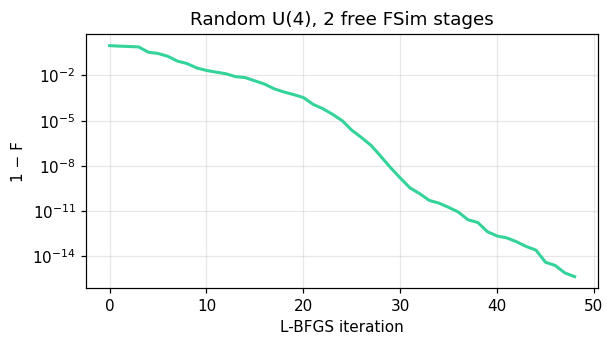

In [3]:
synth = DifferentiableFSimSynthesizer(target_infidelity=1e-9, seed=1)
gates = {"CNOT": cirq.CNOT, "CZ": cirq.CZ, "iSWAP": cirq.ISWAP, "√iSWAP": cirq.SQRT_ISWAP, "SWAP": cirq.SWAP}
print(f"{'gate':8s} stages  1-F        (θ, φ)")
for name, g in gates.items():
    r = synth.decompose(cirq.unitary(g), n_restarts=4)
    print(f"{name:8s} {r.n_stages:5d}   {r.infidelity:.1e}   " + ", ".join(f"({t:+.3f}, {p:+.3f})" for t, p in r.fsim_angles))
r = synth.decompose(haar_random_unitary(4, seed=7), n_restarts=6, max_iter=400)
print(f"random U(4): stages {r.n_stages}, 1-F = {r.infidelity:.1e}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(np.maximum(r.loss_history, 1e-16), lw=2, color="#34d399"); ax.set_xlabel("L-BFGS iteration"); ax.set_ylabel("1 − F"); ax.set_title("Random U(4), 2 free FSim stages")
plt.show()

## 3. Calibrated native gate

On hardware the coupler provides *one* gate. Freezing $(\theta,\varphi)$ to the calibrated values and optimising only the single-qubit dressings gives the minimum number of native applications.

In [4]:
for cal_name, cal in [("Sycamore FSim(π/2, π/6)", CouplerCalibration.sycamore()), ("√iSWAP FSim(π/4, 0)", CouplerCalibration.sqrt_iswap())]:
    print(cal_name)
    for name, g in list(gates.items()) + [("random U(4)", None)]:
        u = haar_random_unitary(4, seed=7) if g is None else cirq.unitary(g)
        r = synth.decompose(u, n_restarts=6, max_iter=300, calibration=cal)
        print(f"   {name:12s} → {r.n_stages} native gate(s), 1-F = {r.infidelity:.1e}")

Sycamore FSim(π/2, π/6)
   CNOT         → 2 native gate(s), 1-F = 0.0e+00
   CZ           → 2 native gate(s), 1-F = 4.4e-16
   iSWAP        → 3 native gate(s), 1-F = 0.0e+00
   √iSWAP       → 2 native gate(s), 1-F = 8.9e-16
   SWAP         → 3 native gate(s), 1-F = 4.4e-16
   random U(4)  → 3 native gate(s), 1-F = 0.0e+00
√iSWAP FSim(π/4, 0)
   CNOT         → 2 native gate(s), 1-F = 2.2e-16
   CZ           → 2 native gate(s), 1-F = 0.0e+00
   iSWAP        → 2 native gate(s), 1-F = 0.0e+00
   √iSWAP       → 1 native gate(s), 1-F = 0.0e+00
   SWAP         → 3 native gate(s), 1-F = 3.2e-12
   random U(4)  → 3 native gate(s), 1-F = 1.1e-15


## 4. Euclidean vs Riemannian solvers

Both minimise the same loss. The Euclidean solver runs L-BFGS-B on Euler angles; the Riemannian solver keeps each dressing $V_j\in U(2)$ and moves along the manifold with Cayley retractions, so every iterate is exactly unitary.

euclidean : stages 2, 1-F = 0.0e+00, 40 iterations, 1.38 s
riemannian: stages 2, 1-F = 6.4e-15, 81 iterations, 3.14 s
riemannian result unitary to 4.4e-15


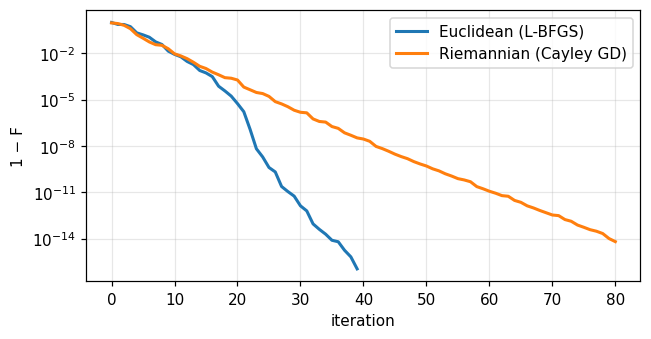

In [5]:
u = haar_random_unitary(4, seed=21)
t0 = time.time(); e = DifferentiableFSimSynthesizer(target_infidelity=1e-10, seed=1).decompose(u, n_restarts=4, max_iter=400); te = time.time() - t0
t0 = time.time(); rm = DifferentiableFSimSynthesizer(target_infidelity=1e-10, seed=1, method="riemannian").decompose(u, n_restarts=4, max_iter=800); tr = time.time() - t0
print(f"euclidean : stages {e.n_stages}, 1-F = {e.infidelity:.1e}, {len(e.loss_history)} iterations, {te:.2f} s")
print(f"riemannian: stages {rm.n_stages}, 1-F = {rm.infidelity:.1e}, {len(rm.loss_history)} iterations, {tr:.2f} s")
U = rm.synthesized_unitary
print("riemannian result unitary to", f"{np.abs(U.conj().T @ U - np.eye(4)).max():.1e}")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.semilogy(np.maximum(e.loss_history, 1e-16), label="Euclidean (L-BFGS)", lw=2)
ax.semilogy(np.maximum(rm.loss_history, 1e-16), label="Riemannian (Cayley GD)", lw=2)
ax.set_xlabel("iteration"); ax.set_ylabel("1 − F"); ax.legend(); plt.show()

## 5. Calibration drift

In [6]:
cm = SycamoreCalibrationMap(seed=3)
for edge in [(0, 1), (1, 2), (2, 3)]:
    cal = cm.get_coupler(*edge)
    r = synth.decompose(cirq.unitary(cirq.CZ), n_restarts=6, calibration=cal)
    print(f"edge {edge}: native FSim({cal.theta_cal:.4f}, {cal.phi_cal:.4f}) → CZ in {r.n_stages} gates, 1-F = {r.infidelity:.1e}")
drifted = cm.perturb(seed=9)
cal2 = drifted.get_coupler(0, 1)
r2 = synth.decompose(cirq.unitary(cirq.CZ), n_restarts=6, calibration=cal2)
print(f"after drift: FSim({cal2.theta_cal:.4f}, {cal2.phi_cal:.4f}) → recompiled CZ 1-F = {r2.infidelity:.1e}")

edge (0, 1): native FSim(1.6116, 0.4853) → CZ in 2 gates, 1-F = 2.2e-16
edge (1, 2): native FSim(1.5792, 0.5151) → CZ in 2 gates, 1-F = 4.4e-16
edge (2, 3): native FSim(1.5617, 0.5204) → CZ in 2 gates, 1-F = 2.2e-16
after drift: FSim(1.5956, 0.4889) → recompiled CZ 1-F = 8.9e-16


## 6. Whole circuits and three-qubit gates

In [7]:
q = cirq.LineQubit.range(3)
circuit = cirq.Circuit(cirq.H(q[0]), cirq.CNOT(q[0], q[1]), cirq.CCNOT(*q), cirq.ISWAP(q[1], q[2]))
compiled = compile_to_fsim(circuit, target_infidelity=1e-8)
print("max qubits per op:", max(len(op.qubits) for op in compiled.all_operations()),
      "| FSim gates:", sum(isinstance(op.gate, cirq.FSimGate) for op in compiled.all_operations()),
      "| fidelity:", round(fid(cirq.unitary(compiled), cirq.unitary(circuit)), 10))
for name, fn, ref in [("Toffoli", decompose_toffoli_to_sycamore, cirq.unitary(cirq.CCNOT(*q))),
                      ("Fredkin", decompose_fredkin_to_sycamore, cirq.unitary(cirq.CSWAP(*q))),
                      ("QFT3", decompose_qft3_to_sycamore, qft_unitary(3))]:
    c = fn(*q, target_infidelity=1e-8)
    print(f"{name:8s}: {sum(isinstance(op.gate, cirq.FSimGate) for op in c.all_operations())} FSim, {len(c)} moments, fidelity {fid(cirq.unitary(c), ref):.10f}")
print(decompose_qft3_to_sycamore(*q).to_text_diagram()[:900])

max qubits per op: 2 | FSim gates: 10 | fidelity: 1.0
Toffoli : 6 FSim, 47 moments, fidelity 1.0000000000
Fredkin : 8 FSim, 61 moments, fidelity 1.0000000000
QFT3    : 4 FSim, 30 moments, fidelity 1.0000000000
                                                                                                                                                          ┌───────────────────────────────┐
0: ───H────────────Rz(1.02π)───Rx(0)────────Rz(0.92π)───FSim(2.2e-09π, -0.5π)───Rz(1.14π)─────Rx(0)───Rz(0.92π)─────Rz(1.12π)───Rx(-π)──────Rz(-0.046π)────FSim(1.35e-10π, 0.25π)─────────────Rz(0.18π)─────Rx(π)───Rz(1.02π)─────Rz(0.932π)───Rx(0.394π)───Rz(-0.11π)─────────────────────────────────────────────────────────────────────────────────────────────────────FSim(0.5π, -1.0π)───Rz(-0.342π)───Rx(0)─────────Rz(-0.894π)───
                                                        │                                                                                                  │                    

## 7. OpenQASM 3 export and round trip

In [8]:
c = compile_to_fsim(cirq.Circuit(cirq.H(q[0]), cirq.CNOT(q[0], q[1])), target_infidelity=1e-9)
text = export_to_openqasm3(c)
print(text[:900])
back = parse_openqasm3(text)
print("round-trip fidelity:", round(fid(cirq.unitary(back), cirq.unitary(c)), 12))

OPENQASM 3.0;
include "stdgates.inc";

// Native tunable-coupler interaction, expressed with stdgates so that any
// OpenQASM 3 toolchain can simulate it. FSim(theta, phi) = exp(-i theta/2 (XX+YY)) cp(-phi).
gate fsim(theta, phi) a, b {
  h a; h b; cx a, b; rz(theta) b; cx a, b; h a; h b;
  sdg a; sdg b; h a; h b; cx a, b; rz(theta) b; cx a, b; h a; h b; s a; s b;
  cp(-phi) a, b;
}

// Pulse-level binding (OpenPulse). Replace the body with the coupler's calibrated
// flux/microwave sequence on the target device.
defcal fsim(theta, phi) $0, $1 {
  // play(frame: coupler_frame, waveform: fsim_pulse(theta, phi));
}

qubit[2] q;

h q[0];
rz(-1.570796327) q[1];
rz(1.547717791) q[0];
rx(-1.570796328) q[1];
rx(-3.141592656) q[0];
rz(3.58092354) q[1];
rz(0.4958531525) q[0];
fsim(3.141592648, 3.14159265) q[0], q[1];
rz(1.767992809) q[0];
rz(2.70226176) q[1];
rx(-3.141592654) q[0];
rx(1.570796333
round-trip fidelity: 1.0
